## Tools Setup

In [1]:
import pathlib, os, sys, operator, re, datetime
from functools import reduce
import numpy as np
import tensorflow as tf
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from keras import Model
import tensorflow_datasets as tfds
from tiny_imagenet import TinyImagenetDataset

# Enable or disable GPU
# To fully disable it, we need to hide all GPU devices from Tensorflow
# Make sure GPU is disabled for this inference part of the lab
ENABLE_GPU = True
# tf.debugging.set_log_device_placement(True)

if not ENABLE_GPU:
    tf.config.set_visible_devices([], 'GPU')

# Print Python and TF version, and where we are running
print(f'Running on Python Version: {sys.version}')
print(f'Using Tensorflow Version: {tf. __version__}')
if not tf.config.experimental.list_physical_devices("GPU"):
    print('Running on CPU')
else:
    print(f'Using GPU at: {tf.test.gpu_device_name()} (of {len(tf.config.experimental.list_physical_devices("GPU"))} available)')

2025-09-07 15:04:37.460113: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-07 15:04:37.478179: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-09-07 15:04:37.491913: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-09-07 15:04:37.491934: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-07 15:04:37.500740: I tensorflow/core/platform/cpu_feature_gua

Running on Python Version: 3.9.21 (main, Feb 10 2025, 00:00:00) 
[GCC 11.5.0 20240719 (Red Hat 11.5.0-5)]
Using Tensorflow Version: 2.16.2
Running on CPU


2025-09-07 15:04:45.115069: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:134] retrieving CUDA diagnostic information for host: co2050-20.ece.iastate.edu
2025-09-07 15:04:45.115099: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:141] hostname: co2050-20.ece.iastate.edu
2025-09-07 15:04:45.115190: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:165] libcuda reported version is: NOT_FOUND: was unable to find libcuda.so DSO loaded into this program
2025-09-07 15:04:45.115228: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:169] kernel reported version is: NOT_FOUND: could not find kernel module information in driver version file contents: "NVRM version: NVIDIA UNIX Open Kernel Module for x86_64  580.65.06  Release Build  (root@co2050-20.ece.iastate.edu)  Fri Aug 15 15:09:34 CDT 2025
GCC version:  gcc version 11.5.0 20240719 (Red Hat 11.5.0-5) (GCC) 
"


## Dataset Inspection

In [2]:
# This cell imports our dataset.

# Original Source: https://github.com/ksachdeva/tiny-imagenet-tfds
# Class Version Source: https://github.com/duweisu/tiny-imagenet-tfds
# Setup our dataset
# ---------------------------------------------------------

tiny_imagenet_builder = TinyImagenetDataset()

# this call (download_and_prepare) will trigger the download of the dataset
# and preparation (conversion to tfrecords)
#
# This will be done only once and on next usage tfds will
# use the cached version on your host.
tiny_imagenet_builder.download_and_prepare(download_dir="~/tensorflow-datasets/downloads")

# class_names = tiny_imagenet_builder.info.features['label'].names
ds = tiny_imagenet_builder.as_dataset()
ds_train, ds_val = ds["train"], ds["validation"]
assert(isinstance(ds_train, tf.data.Dataset))
assert(isinstance(ds_val, tf.data.Dataset))

# Training Dataset
ds_train = ds_train.shuffle(1024).prefetch(tf.data.AUTOTUNE)

# Validation Dataset
ds_val = ds_val.shuffle(1024).prefetch(tf.data.AUTOTUNE)

# Dataset metadata
ds_info = tiny_imagenet_builder.info

In [3]:
# We need to read the "human readable" labels so we can translate with the numeric values
# Read the labels file (words.txt)
with open(os.path.abspath('wnids.txt'), 'r') as f:
    wnids = [x.strip() for x in f]

# Map wnids to integer labels
wnid_to_label = {wnid: i for i, wnid in enumerate(wnids)}
label_to_wnid = {v: k for k, v in wnid_to_label.items()}

# Use words.txt to get names for each class
with open(os.path.abspath('words.txt'), 'r') as f:
    wnid_to_words = dict(line.split('\t') for line in f)
    for wnid, words in wnid_to_words.items():
        wnid_to_words[wnid] = [w.strip() for w in words.split(',')]
        
class_names = [str(wnid_to_words[wnid]) for wnid in wnids]

In [4]:
# Helper function to get the label name
def img_class(img_data, idx=None):
    image, label, id, label_name = img_data["image"], img_data["label"], img_data["id"], img_data["metadata"]['label_name']
    # Handle batches of images correctly
    if idx != None:
        image, label, id, label_name = img_data["image"][idx], img_data["label"][idx], img_data["id"][idx], img_data["metadata"]['label_name'][idx]
    
    return f"{label_name} (class index: {label} - id: {id})"


# Helper function to show basic info about an image
def img_info(img, idx=None, display=True, title_apend=""):
    image = img['image']

    # Print the class
    class_str = img_class(img, idx)
    print(f"Label: {class_str}")
    
    # Display the image
    if display:
        plt.figure()
        plt.title(title_apend + class_str)
        # Handle batches correctly
        if image.shape.ndims > 3:
            plt.imshow(image.numpy().reshape(64, 64, 3))
        else:
            plt.imshow(image.numpy())

--- Train & Validation dataset info ---
Train: <_PrefetchDataset element_spec={'id': TensorSpec(shape=(), dtype=tf.string, name=None), 'image': TensorSpec(shape=(64, 64, 3), dtype=tf.uint8, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None), 'metadata': {'label_name': TensorSpec(shape=(), dtype=tf.string, name=None)}}>
Validation: <_PrefetchDataset element_spec={'id': TensorSpec(shape=(), dtype=tf.string, name=None), 'image': TensorSpec(shape=(64, 64, 3), dtype=tf.uint8, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None), 'metadata': {'label_name': TensorSpec(shape=(), dtype=tf.string, name=None)}}>

--- Show an example image ---
Label: b'standard poodle' (class index: 194 - id: b'n02113799')

 Show some other examples


2025-09-07 15:04:45.362840: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-09-07 15:04:45.383797: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-07 15:04:45.468649: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.

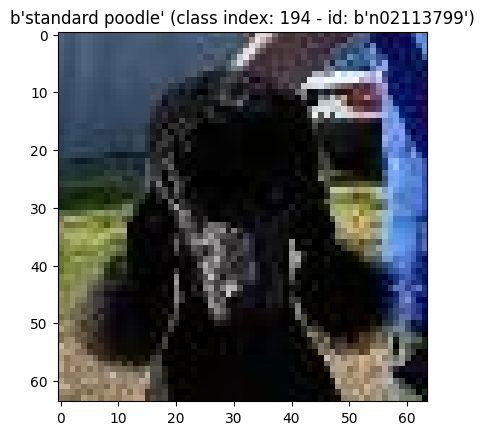

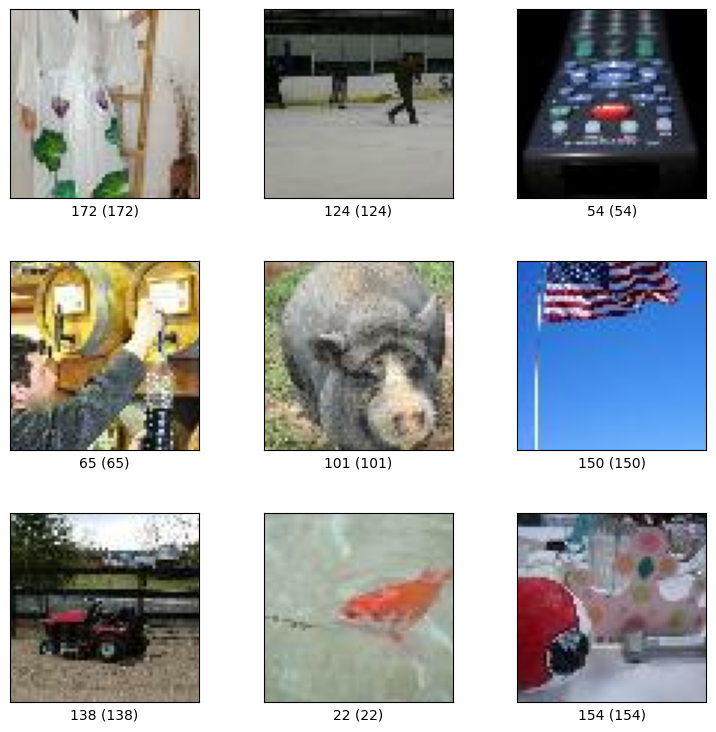

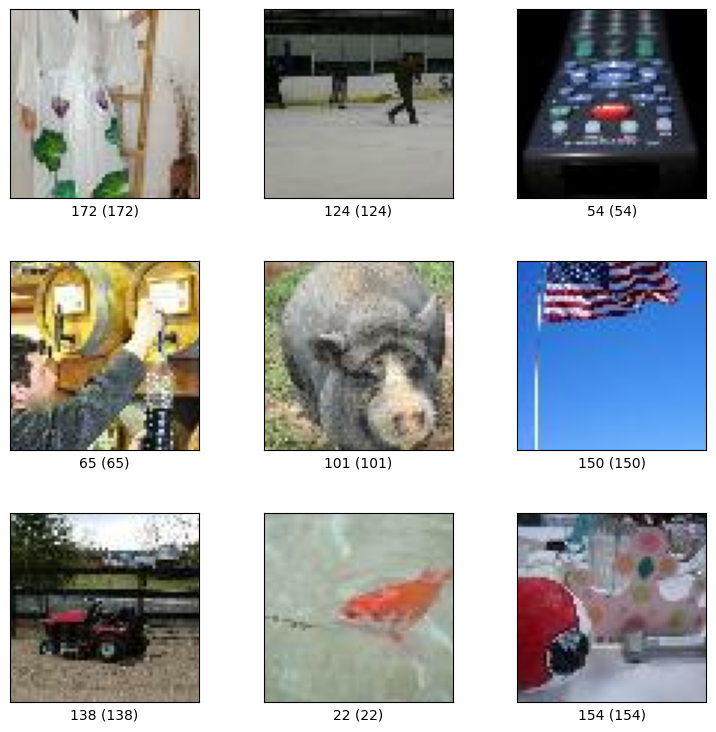

In [5]:
# Print the dataset types and info
print("--- Train & Validation dataset info ---")
print(f"Train: {ds_train}")
print(f"Validation: {ds_val}")
# print(f"Dataset Info: {ds_info}") # Uncomment to print Dataset info

print("\n--- Show an example image ---")
for example in ds_val.take(1):
    img_info(example)

print("\n Show some other examples")
tfds.show_examples(ds_val, ds_info, rows=3, cols=3)


--- Image 0 ---


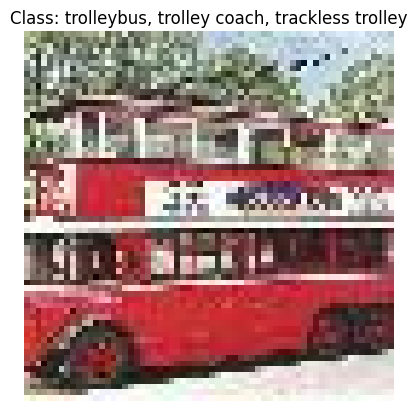

Data type: <dtype: 'uint8'>
Dimensions: (64, 64, 3)
Memory required: 12288 bytes
Label: 152
ID: n04487081
Class name: trolleybus, trolley coach, trackless trolley

--- Image 1 ---


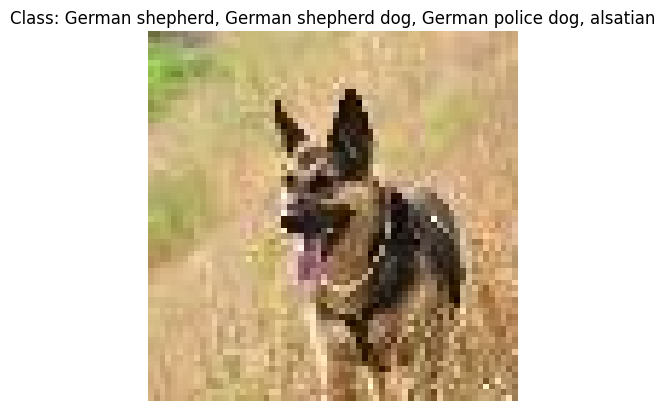

Data type: <dtype: 'uint8'>
Dimensions: (64, 64, 3)
Memory required: 12288 bytes
Label: 11
ID: n02106662
Class name: German shepherd, German shepherd dog, German police dog, alsatian

--- Image 2 ---


2025-09-07 15:04:46.215642: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


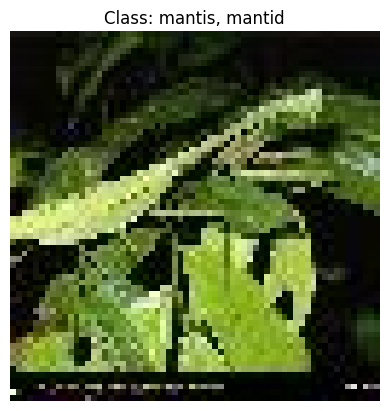

Data type: <dtype: 'uint8'>
Dimensions: (64, 64, 3)
Memory required: 12288 bytes
Label: 51
ID: n02236044
Class name: mantis, mantid


2025-09-07 15:04:46.246860: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [6]:
# TODO: Print and visualize three inputs from the validation set
#     : Print the stroage data type
#     : Print and note the dimensions of each image
#     : Print the memory required to store each image

# Sample Images
import matplotlib.pyplot as plt

# Sample Images
sample_imgs = []
for index, img_data in enumerate(ds_val.take(3)):
    sample_imgs.append(img_data)
    image, label, id, label_name = img_data["image"], img_data["label"], img_data["id"], img_data["metadata"]['label_name']

    print(f'\n--- Image {index} ---')

    # Display image
    plt.imshow(image.numpy())
    plt.title(f'Class: {label_name.numpy().decode("utf-8")}')
    plt.axis('off')
    plt.show()

    # Print storage data type
    print(f'Data type: {image.dtype}')

    # Print image dimensions
    print(f'Dimensions: {image.shape}')

    # Calculate memory required (in bytes)
    memory_bytes = tf.size(image).numpy() * image.dtype.size
    print(f'Memory required: {memory_bytes} bytes')

    # Print label and ID
    print(f'Label: {label.numpy()}')
    print(f'ID: {id.numpy().decode("utf-8")}')
    print(f'Class name: {label_name.numpy().decode("utf-8")}')


In [7]:
# TODO: Export each of the three inputs to a binary file which will be used to load the images into C++ later
# NOTE: First flatten the array (ex: 4D --> 1D). So 64*64*3 = 12288 element 1D array

# Make a directory for our image data
img_dir = os.path.abspath('img_data')
pathlib.Path(img_dir).mkdir(exist_ok=True)

# Create a metadata file
metadata_file = open(os.path.join(img_dir, f'metadata.txt'), 'w')
metadata_file.write(f'Number\t\tDims\t\tClass Data\n')

# Export each image
for index, img_data in enumerate(sample_imgs):    
    img_file = open(os.path.join(img_dir, f'image_{index}.bin'), 'wb')
    
    # TODO: Your Code Here
    # Extract image and metadata
    image = img_data["image"].numpy()
    label_name = img_data["metadata"]["label_name"].numpy().decode("utf-8")

    # Flatten the image to 1D array (64*64*3 = 12288)
    flat_image = image.flatten()

    # Write binary data to file
    flat_image.tofile(img_file)
    img_file.close()

    # Write metadata info to text file
    dims_str = f'{image.shape[0]}x{image.shape[1]}x{image.shape[2]}'
    metadata_file.write(f'{index}\t\t{dims_str}\t\t{label_name}\n')

# Close metadata file
metadata_file.close()
    

## Model Loading and Inference

In [8]:
# TODO: Load the model
# Now we will load the H5 model! Please make sure the h5 model file is present in the below directory.
# You can download this from the Canvas Page and place it in the same directory as this notebook.

# model_path = os.path.abspath(""/home/<NETID>/path/to/your/lab1/CNN_TinyImageNet.h5)" # Uncomment this to use a non-relative path
model_path = os.path.abspath("CNN_TinyImageNet.h5")
model = tf.keras.models.load_model(model_path)
model.summary()
# TODO: Your Code Here
#model =


/home/rafatmom/Downloads/cpre-487-587-lab1/lab1_venv/lib64/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/rafatmom/Downloads/cpre-487-587-lab1/lab1_venv/lib64/python3.9/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 60, 60, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 56, 56, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        51,400 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 770,218 (2.94 MB)

 Trainable params: 770,216 (2.94 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

Label: [b'ladybug, ladybeetle, lady beetle, ladybird, ladybird beetle'] (class index: [76] - id: [b'n02165456'])


2025-09-07 15:04:46.439460: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


2025-09-07 15:04:46.584135: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Best Guess [class index]: ['ladybug', 'ladybeetle', 'lady beetle', 'ladybird', 'ladybird beetle'] [76]
Best Guess Confidence (percent / 1.0): [0.58678097]
Top 15 Guesses (class index): ["['ladybug', 'ladybeetle', 'lady beetle', 'ladybird', 'ladybird beetle'] [76]", "['bee'] [87]", "['pomegranate'] [170]", "['slug'] [100]", "['snorkel'] [111]", "['fly'] [113]", "['sea slug', 'nudibranch'] [165]", "['goldfish', 'Carassius auratus'] [22]", '[\'dragonfly\', \'darning needle\', "devil\'s darning needle", \'sewing needle\', \'snake feeder\', \'snake doctor\', \'mosquito hawk\', \'skeeter hawk\'] [105]', "['bell pepper'] [188]", "['acorn'] [195]", "['cockroach', 'roach'] [48]", "['snail'] [33]", "['banana'] [46]", "['sulphur butterfly', 'sulfur butterfly'] [42]"]
Top 15 Guesses Confidence (percent / 1.0): [[0.58678097 0.1502498  0.06192693 0.03079292 0.02737168 0.02675704
  0.02058914 0.02035242 0.01752059 0.00767472 0.00585177 0.00385585
  0.00325067 0.0031371  0.00292419]]


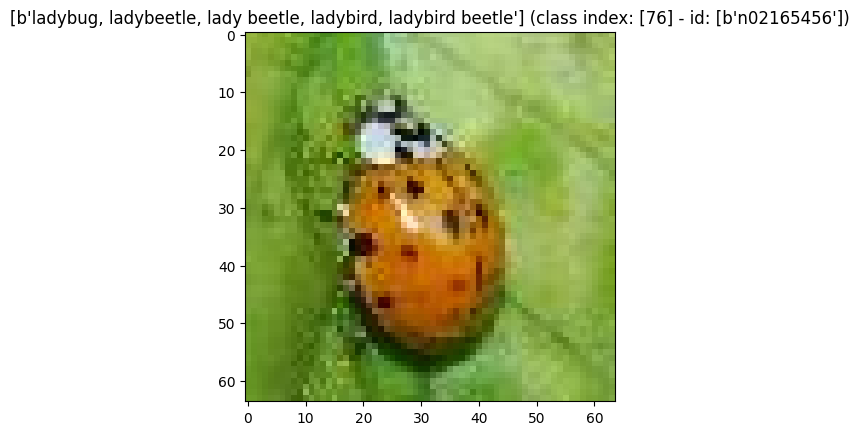

In [9]:
# Running infrence on our model
# We can run an infrence of our model by doing the following (we are doing batches of 1 here)
for example in ds_train.batch(1).take(1):
    img_info(example)
    
    # Make a prediction
    pred = model.predict(tf.cast(example["image"], tf.float32)/255.0)
    # print(f'Raw 200 Class Weighted Prediction:\n{pred}') # Uncomment to see the raw prediction
    
    # What is out best guess?
    best_guess = tf.math.argmax(pred, axis=1).numpy() # Our output is 200 weighted value, we want the most likely
    print(f'Best Guess [class index]: {class_names[best_guess[0]]} [{best_guess[0]}]')
    print(f'Best Guess Confidence (percent / 1.0): {pred[0][best_guess]}')

    # What are our top 15 guesses?
    top_15 = tf.math.top_k(pred, k=15)
    print(f'Top 15 Guesses (class index): {[f"{class_names[idx]} [{idx}]" for idx in top_15.indices[0]]}')
    print(f'Top 15 Guesses Confidence (percent / 1.0): {top_15.values}')

In [10]:
print(f"{'Image':<10}{'Actual Class':<25}{'Predicted Class':<25}{'Confidence':<10}")
print("-" * 70)

for i, example in enumerate(sample_imgs):
    image = tf.cast(example["image"], tf.float32) / 255.0
    input_img = tf.expand_dims(image, axis=0)

    pred = model.predict(input_img)[0]
    best_guess = tf.math.argmax(pred).numpy()
    confidence = pred[best_guess]
    actual_class = example["metadata"]["label_name"].numpy().decode("utf-8")

    print(f"{i:<10}{actual_class:<25}{class_names[best_guess]:<25}{confidence:.4f}")


Image     Actual Class             Predicted Class          Confidence
----------------------------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
0         trolleybus, trolley coach, trackless trolley['trolleybus', 'trolley coach', 'trackless trolley']0.6686
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1         German shepherd, German shepherd dog, German police dog, alsatian['German shepherd', 'German shepherd dog', 'German police dog', 'alsatian']0.3541
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2         mantis, mantid           ['walking stick', 'walkingstick', 'stick insect']0.5044


In [11]:
# Initialize counters
total = acc_top1 = acc_top5 = acc_top10 = 0
batch_size = 64  # You can adjust this based on your system's memory

for batch in ds_val.batch(batch_size).take(10000 // batch_size):
    images = tf.cast(batch["image"], tf.float32) / 255.0
    labels = batch["label"].numpy()

    preds = model.predict(images)  # Shape: (batch_size, num_classes)
    top_10 = tf.math.top_k(preds, k=10).indices.numpy()

    for i in range(len(labels)):
        true_label = labels[i]
        top_preds = top_10[i]

        total += 1
        if true_label == top_preds[0]:
            acc_top1 += 1
        if true_label in top_preds[:5]:
            acc_top5 += 1
        if true_label in top_preds:
            acc_top10 += 1

# Print results
print("\n✅ Model Accuracy:")
print(f"Total Samples Evaluated: {total}")
print(f"Top-1 Accuracy:  {acc_top1 / total:.4f}")
print(f"Top-5 Accuracy:  {acc_top5 / total:.4f}")
print(f"Top-10 Accuracy: {acc_top10 / total:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━

2025-09-07 15:04:58.362214: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [12]:
print(f"Total Classes: {len(class_names)}")

train_count = sum(1 for _ in ds_train)
val_count = sum(1 for _ in ds_val)

print(f"Training Samples: {train_count}")
print(f"Validation Samples: {val_count}")


Total Classes: 200


2025-09-07 15:05:03.981831: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Training Samples: 100000
Validation Samples: 10000


2025-09-07 15:05:04.534275: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Model Exploration

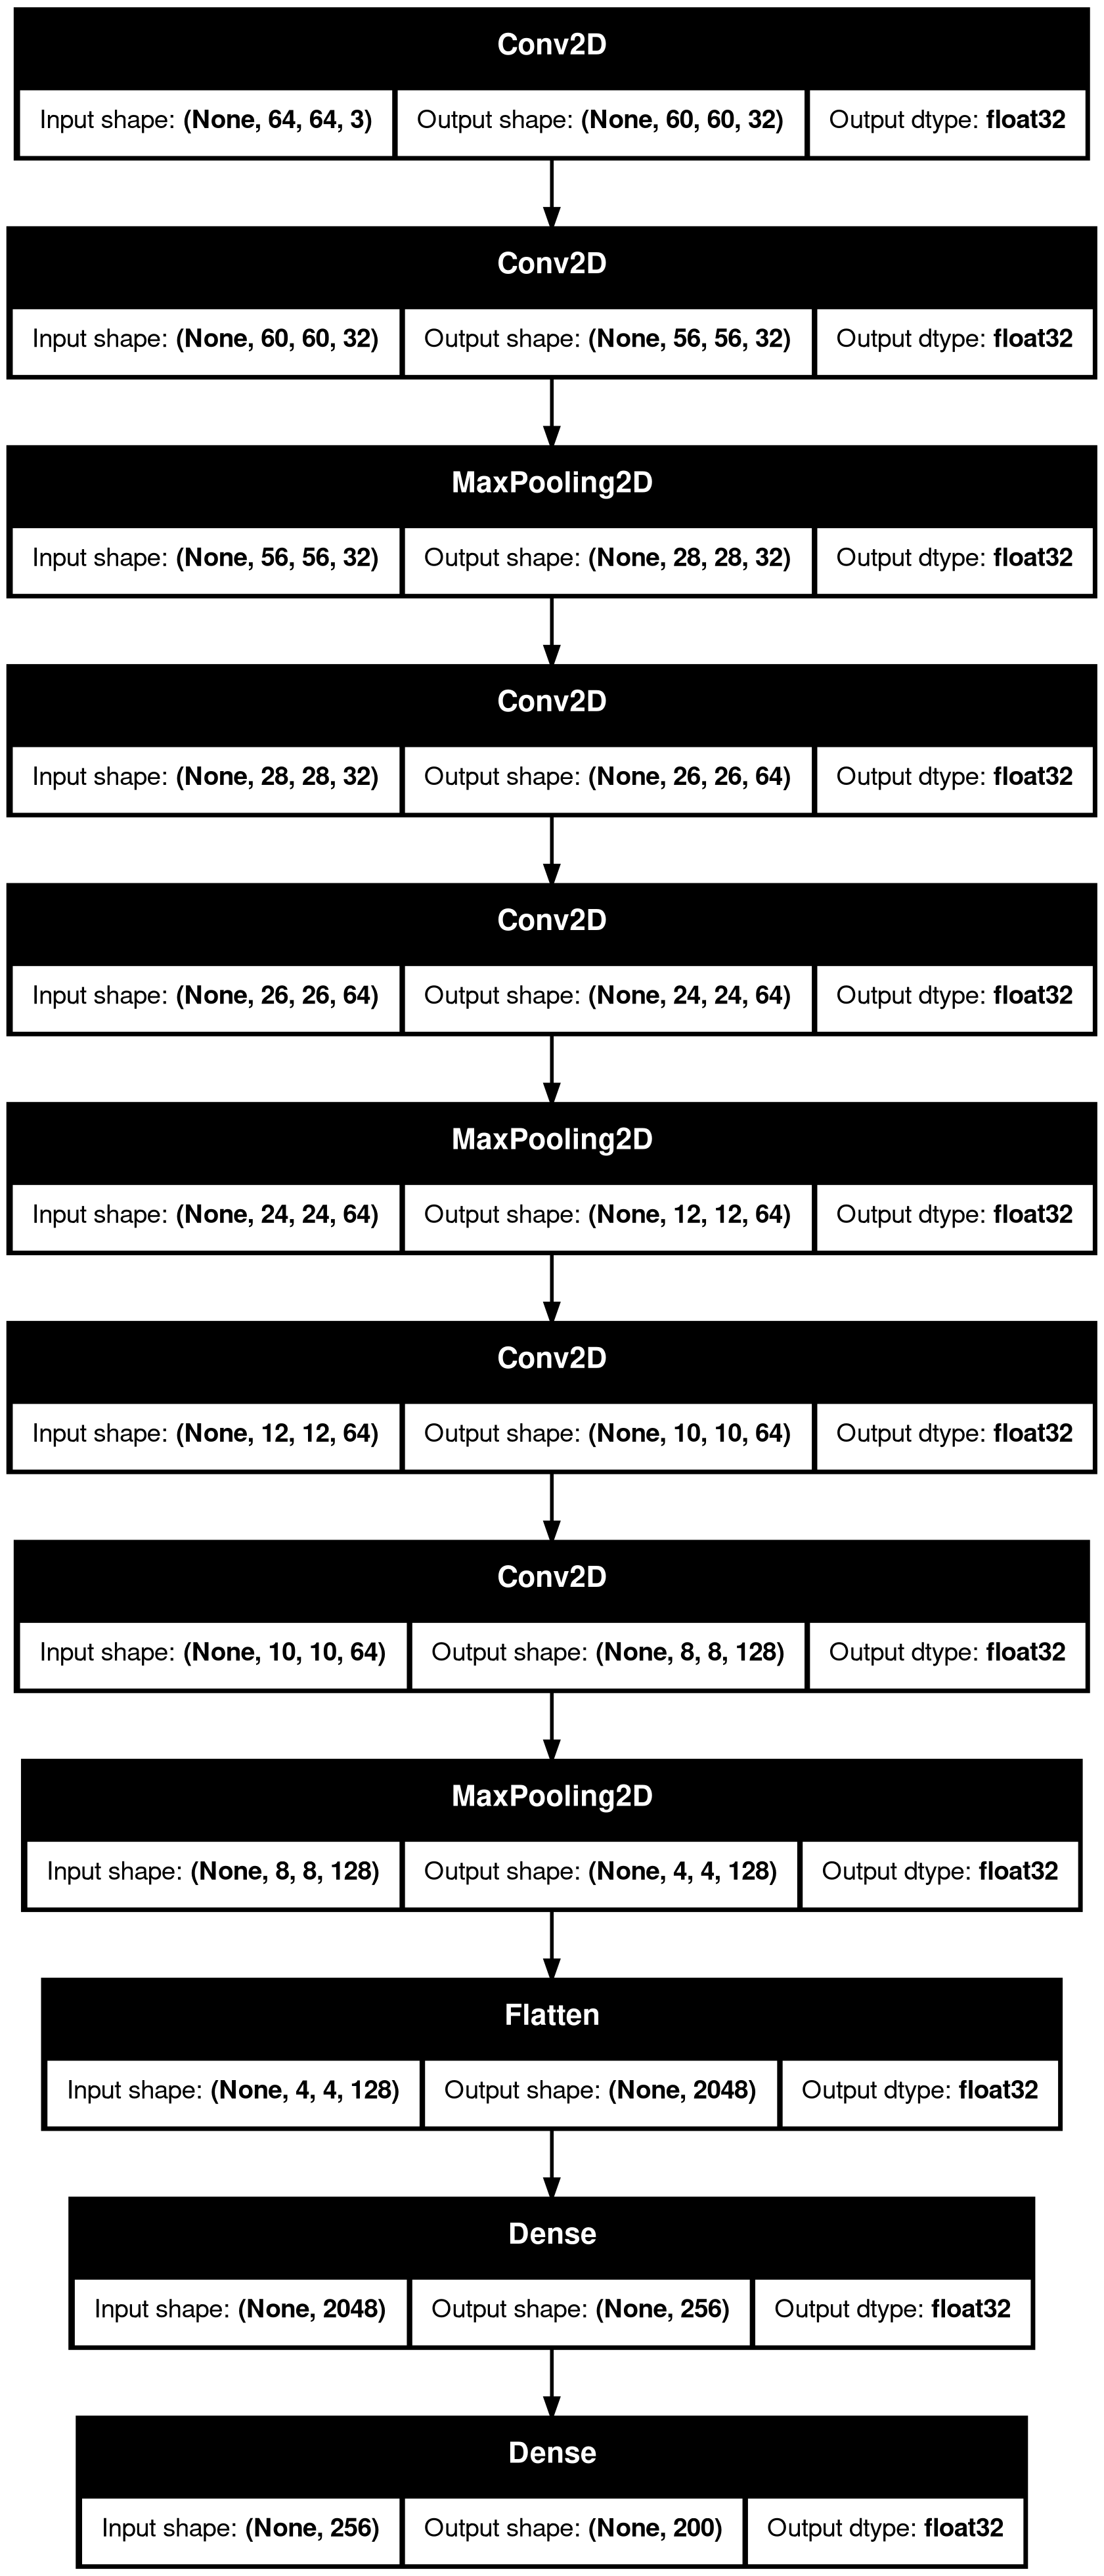

In [13]:
# TODO: Visualize the model in Netron (https://netron.app/) and include an image here.

tf.keras.utils.plot_model(model, "model.png", show_shapes=True, show_dtype=True, expand_nested=True) 

Layer: conv2d_1
Data type: float32
Shape: (5, 5, 32, 32)
Memory: 100.00 KB


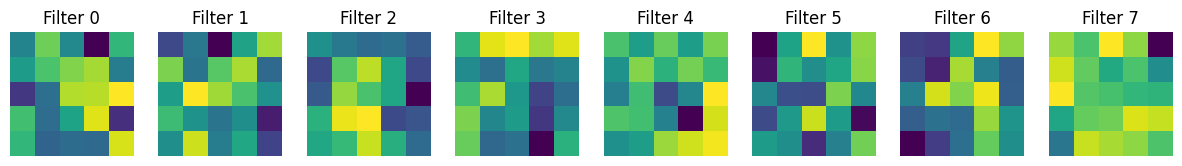

Layer: conv2d_5
Data type: float32
Shape: (3, 3, 64, 128)
Memory: 288.00 KB


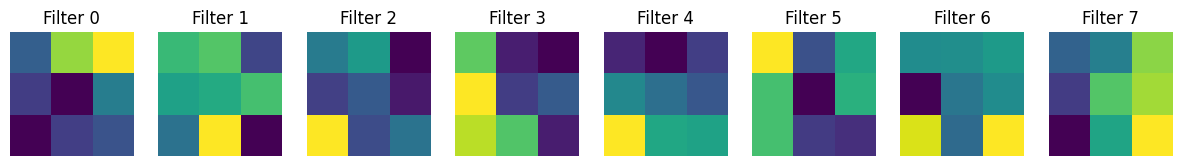

In [14]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_conv_weights(layer_name, model):
    weights = model.get_layer(layer_name).get_weights()[0]  # shape: (H, W, in_channels, out_channels)
    print(f"Layer: {layer_name}")
    print(f"Data type: {weights.dtype}")
    print(f"Shape: {weights.shape}")
    print(f"Memory: {weights.nbytes / 1024:.2f} KB")

    # Visualize first few filters
    num_filters = min(weights.shape[-1], 8)
    fig, axes = plt.subplots(1, num_filters, figsize=(15, 5))
    for i in range(num_filters):
        kernel = weights[:, :, :, i]
        kernel_img = np.mean(kernel, axis=-1)  # average over input channels
        axes[i].imshow(kernel_img, cmap='viridis')
        axes[i].axis('off')
        axes[i].set_title(f'Filter {i}')
    plt.show()

# Example usage
visualize_conv_weights("conv2d_1", model)  # near input
visualize_conv_weights("conv2d_5", model)  # near output



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Layer: conv2d_1
Data type: float32
Shape: (56, 56, 32)
Memory: 392.00 KB


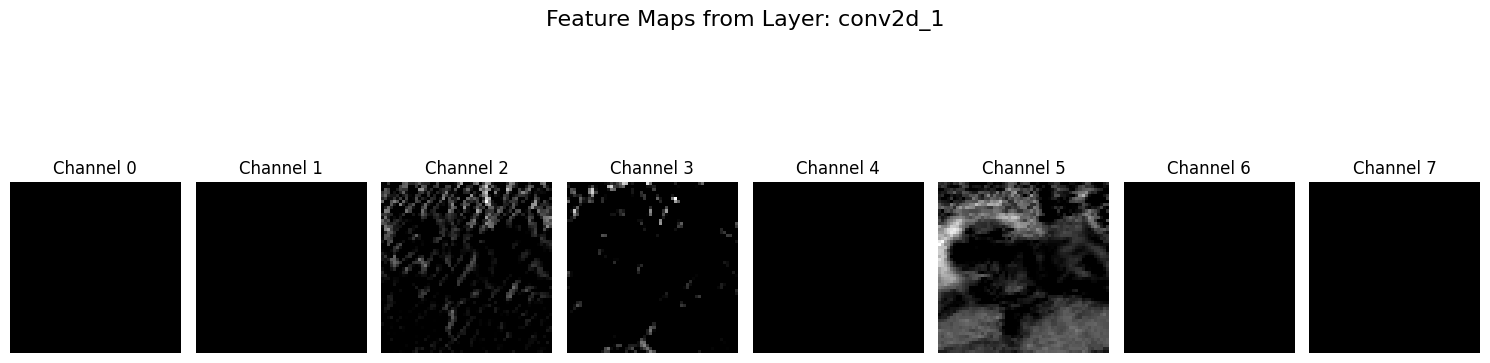

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Layer: conv2d_5
Data type: float32
Shape: (8, 8, 128)
Memory: 32.00 KB


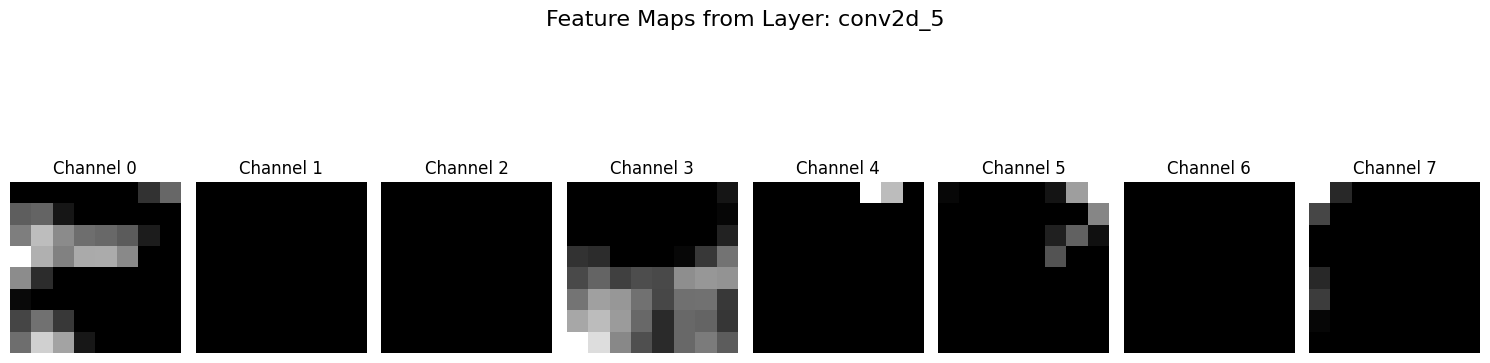

In [15]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model

# Load and preprocess a sample image from your dataset
sample_image = tf.cast(ds_val.take(1).as_numpy_iterator().next()["image"], tf.float32) / 255.0
sample_input = tf.expand_dims(sample_image, axis=0)

# Call the model once to build it
_ = model(sample_input)

# Helper function to get intermediate output from a layer
def get_feature_map_model(layer_name):
    layer_output = model.get_layer(layer_name).output
    feature_model = Model(inputs=model.layers[0].input, outputs=layer_output)
    return feature_model

# Visualization function
def visualize_feature_maps(image, layer_name, num_channels=8):
    feature_model = get_feature_map_model(layer_name)
    feature_maps = feature_model.predict(tf.expand_dims(image, axis=0))[0]

    print(f"Layer: {layer_name}")
    print(f"Data type: {feature_maps.dtype}")
    print(f"Shape: {feature_maps.shape}")
    print(f"Memory: {feature_maps.nbytes / 1024:.2f} KB")

    # Plot feature maps
    num_channels = min(feature_maps.shape[-1], num_channels)
    fig, axes = plt.subplots(1, num_channels, figsize=(15, 5))
    for i in range(num_channels):
        axes[i].imshow(feature_maps[:, :, i], cmap='gray')
        axes[i].axis('off')
        axes[i].set_title(f'Channel {i}')
    plt.suptitle(f'Feature Maps from Layer: {layer_name}', fontsize=16)
    plt.tight_layout()
    plt.show()

# Visualize feature maps from early and late convolutional layers
visualize_feature_maps(sample_image, "conv2d_1")  # Early layer
visualize_feature_maps(sample_image, "conv2d_5")  # Late layer


In [16]:
import os
import re
import pathlib
import numpy as np

# Create directory to store weights
model_dir = os.path.abspath('model_data')
pathlib.Path(model_dir).mkdir(exist_ok=True)

# Export weights and biases for conv and dense layers
conv_index = dense_index = 1  # layer index starts from one
for layer_idx, layer in enumerate(model.layers):
    if re.match(r'(conv|dense)', layer.name):
        weight_file_name = os.path.join(model_dir, f'{layer.name}_weights.bin')
        bias_file_name = os.path.join(model_dir, f'{layer.name}_bias.bin')
    else:
        continue

    # Ensure layer has weights
    assert layer.weights[0].name.endswith('kernel')
    assert layer.weights[1].name.endswith('bias')

    # Extract weights and biases as numpy arrays
    weights = layer.get_weights()[0]  # kernel
    biases = layer.get_weights()[1]  # bias

    # Export to binary files
    weights.astype(np.float32).tofile(weight_file_name)
    biases.astype(np.float32).tofile(bias_file_name)

    print(f"Exported {layer.name}:")
    print(f"  Weights → {weight_file_name} ({weights.shape})")
    print(f"  Biases  → {bias_file_name} ({biases.shape})")


Exported conv2d:
  Weights → /home/rafatmom/Downloads/cpre-487-587-lab1/model_data/conv2d_weights.bin ((5, 5, 3, 32))
  Biases  → /home/rafatmom/Downloads/cpre-487-587-lab1/model_data/conv2d_bias.bin ((32,))
Exported conv2d_1:
  Weights → /home/rafatmom/Downloads/cpre-487-587-lab1/model_data/conv2d_1_weights.bin ((5, 5, 32, 32))
  Biases  → /home/rafatmom/Downloads/cpre-487-587-lab1/model_data/conv2d_1_bias.bin ((32,))
Exported conv2d_2:
  Weights → /home/rafatmom/Downloads/cpre-487-587-lab1/model_data/conv2d_2_weights.bin ((3, 3, 32, 64))
  Biases  → /home/rafatmom/Downloads/cpre-487-587-lab1/model_data/conv2d_2_bias.bin ((64,))
Exported conv2d_3:
  Weights → /home/rafatmom/Downloads/cpre-487-587-lab1/model_data/conv2d_3_weights.bin ((3, 3, 64, 64))
  Biases  → /home/rafatmom/Downloads/cpre-487-587-lab1/model_data/conv2d_3_bias.bin ((64,))
Exported conv2d_4:
  Weights → /home/rafatmom/Downloads/cpre-487-587-lab1/model_data/conv2d_4_weights.bin ((3, 3, 64, 64))
  Biases  → /home/rafatm

In [17]:
import os
import pathlib
import numpy as np
import tensorflow as tf

# Create directory to store intermediate outputs
img_dir = os.path.abspath('img_data')
pathlib.Path(img_dir).mkdir(exist_ok=True)

# Loop through each image
for img_idx, img in enumerate(sample_imgs):
    file_dir = os.path.join(img_dir, f'test_input_{img_idx}')
    pathlib.Path(file_dir).mkdir(exist_ok=True)

    # Extract and preprocess image
    input_tensor = tf.expand_dims(tf.cast(img["image"], tf.float32) / 255.0, axis=0)

    # Run the model once to build it
    _ = model(input_tensor)

    for layer in model.layers:
        try:
            intermediate_model = tf.keras.Model(inputs=model.layers[0].input, outputs=layer.output)
            output = intermediate_model.predict(input_tensor)[0]

            output_file = os.path.join(file_dir, f'{layer.name}_output.bin')
            output.astype(np.float32).tofile(output_file)

            print(f"Saved output of layer '{layer.name}' for image {img_idx} → {output.shape}")
        except Exception as e:
            print(f"Skipping layer '{layer.name}': {e}")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Saved output of layer 'conv2d' for image 0 → (60, 60, 32)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Saved output of layer 'conv2d_1' for image 0 → (56, 56, 32)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Saved output of layer 'max_pooling2d' for image 0 → (28, 28, 32)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Saved output of layer 'conv2d_2' for image 0 → (26, 26, 64)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Saved output of layer 'conv2d_3' for image 0 → (24, 24, 64)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Saved output of layer 'max_pooling2d_1' for image 0 → (12, 12, 64)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Saved output of layer 'conv2d_4' for image 0 → (10, 10, 64)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Saved output of layer 'conv2d_5' for image 0 → (8, 8, 128)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Saved output of layer 'max_pooling2d_2' for image 0 → (4, 4, 128)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Saved output of layer 'flatten' for image 0 → (2048,)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Saved output of layer 'dense' for image 0 → (256,)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Saved output of layer 'dense_1' for image 0 → (200,)
1/1 ━━━━━━━━━━━━━━━━━━━━ 

## Tensorboard

In [18]:
import tensorflow as tf
import os
import datetime
import pathlib

# Profiler options
tf.profiler.experimental.ProfilerOptions(
    host_tracer_level=1, python_tracer_level=0, device_tracer_level=1
)

# Create log directory
log_dir = os.path.abspath(os.path.join('log_data'))
log_dir_run = os.path.abspath(os.path.join(log_dir, datetime.datetime.now().strftime("%Y%m%d-%H%M%S")))
pathlib.Path(log_dir_run).mkdir(exist_ok=True, parents=True)

# Stop any existing profiler session
try:
    tf.profiler.experimental.stop()
except:
    pass


In [19]:
import tensorflow as tf
import os
import datetime
import pathlib
import time

# Profiler options (optional: you can pass this into start if needed)
profiler_options = tf.profiler.experimental.ProfilerOptions(
    host_tracer_level=1,
    python_tracer_level=0,
    device_tracer_level=1
)

# Create log directory
log_dir = os.path.abspath(os.path.join('log_data'))
log_dir_run = os.path.abspath(os.path.join(log_dir, datetime.datetime.now().strftime("%Y%m%d-%H%M%S")))
pathlib.Path(log_dir_run).mkdir(exist_ok=True, parents=True)

# Stop any existing profiler session
try:
    tf.profiler.experimental.stop()
except:
    pass

# Start profiler
tf.profiler.experimental.start(log_dir_run)

# Define your model and dataset
# Example: Load a pretrained model and dummy dataset
model = tf.keras.applications.MobileNetV2(weights='imagenet', input_shape=(224, 224, 3), include_top=True)
dummy_image = tf.random.uniform((1, 224, 224, 3))

# Run inference with trace
@tf.function
def run_inference(image):
    return model(image)

with tf.profiler.experimental.Trace("inference", step_num=0, _r=1):
    start_time = time.time()
    _ = run_inference(dummy_image)
    end_time = time.time()

latency_ms = (end_time - start_time) * 1000
print(f"Inference latency: {latency_ms:.2f} ms")

# Stop profiler
tf.profiler.experimental.stop()


2025-09-07 15:05:08.718580: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:104] Profiler session initializing.
2025-09-07 15:05:08.718596: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:119] Profiler session started.


Inference latency: 524.07 ms


2025-09-07 15:05:09.909042: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:70] Profiler session collecting data.
2025-09-07 15:05:09.920252: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:131] Profiler session tear down.
2025-09-07 15:05:09.924022: I external/local_tsl/tsl/profiler/rpc/client/save_profile.cc:144] Collecting XSpace to repository: /home/rafatmom/Downloads/cpre-487-587-lab1/log_data/20250907-150508/plugins/profile/2025_09_07_15_05_09/co2050-20.ece.iastate.edu.xplane.pb


In [20]:
# Load TensorBoard extension
%load_ext tensorboard

# Print the log directory path for confirmation
print("TensorBoard log directory:", log_dir)

# Launch TensorBoard on port 6006
%tensorboard --logdir=$log_dir --port=6006


TensorBoard log directory: /home/rafatmom/Downloads/cpre-487-587-lab1/log_data


In [21]:
import tensorflow as tf
import os
import datetime
import pathlib
import time

# Load TensorBoard extension (for Jupyter)
%load_ext tensorboard

# Create log directory
log_dir = os.path.abspath('log_data')
log_dir_run = os.path.join(log_dir, datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
pathlib.Path(log_dir_run).mkdir(exist_ok=True, parents=True)

# Stop any existing profiler session
try:
    tf.profiler.experimental.stop()
except:
    pass

# Load a pretrained model
model = tf.keras.applications.MobileNetV2(weights='imagenet', input_shape=(224, 224, 3), include_top=True)

# Create dummy validation dataset
ds_val = tf.data.Dataset.from_tensor_slices(
    tf.random.uniform((1000, 224, 224, 3))
).map(lambda x: {"image": x}).batch(1)

# Online Inference Profiling
loop_index = [10, 100, 1000]
results = {}

for idx in loop_index:
    print(f"\nRunning online inference for {idx} images...")

    # Start profiler
    tf.profiler.experimental.start(log_dir_run)

    # Warm-up
    _ = model(tf.random.uniform((1, 224, 224, 3)))

    # Start timing
    start_time = time.time()

    # Run inference
    for i, example in enumerate(ds_val.take(idx)):
        image = tf.cast(example["image"], tf.float32)
        _ = model(image)

    # End timing
    end_time = time.time()

    # Stop profiler
    tf.profiler.experimental.stop()

    # Calculate metrics
    total_latency = (end_time - start_time) * 1000  # ms
    throughput = idx / (end_time - start_time)      # images/sec

    results[idx] = {
        "latency_ms": total_latency,
        "throughput_ips": throughput
    }

    print(f"Total latency for {idx} images: {total_latency:.2f} ms")
    print(f"Throughput: {throughput:.2f} images/sec")

# Print summary
print("\n--- Profiling Summary ---")
for k, v in results.items():
    print(f"{k} images → Latency: {v['latency_ms']:.2f} ms, Throughput: {v['throughput_ips']:.2f} img/sec")

# Launch TensorBoard
print("\nLaunching TensorBoard...")
print("Log directory:", log_dir)
%tensorboard --logdir=$log_dir --port=6006


The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard

Running online inference for 10 images...


2025-09-07 15:05:14.448245: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:104] Profiler session initializing.
2025-09-07 15:05:14.448260: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:119] Profiler session started.
2025-09-07 15:05:16.096517: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-07 15:05:16.098446: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:70] Profiler session collecting data.
2025-09-07 15:05:16.144580: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:131] Profiler session tear down.
2025-09-07 15:05:16.146659: I external/local_tsl/tsl/profiler/rpc/client/save_profile.cc:144] Collecting XSpace to repository: /home/rafatmom/Downloads/cpre-487-587-lab1/log_data/20250907-150514/plugins/profile/2025_09_07_15_05_16/co2050-20.ece.iastate.edu.xplane.pb
2025-09-07 15:05:16.169691: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:104] Profile

Total latency for 10 images: 1484.75 ms
Throughput: 6.74 images/sec

Running online inference for 100 images...


2025-09-07 15:05:29.566029: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-07 15:05:29.567034: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:70] Profiler session collecting data.
2025-09-07 15:05:30.006028: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:131] Profiler session tear down.
2025-09-07 15:05:30.007364: I external/local_tsl/tsl/profiler/rpc/client/save_profile.cc:144] Collecting XSpace to repository: /home/rafatmom/Downloads/cpre-487-587-lab1/log_data/20250907-150514/plugins/profile/2025_09_07_15_05_30/co2050-20.ece.iastate.edu.xplane.pb


Total latency for 100 images: 13264.76 ms
Throughput: 7.54 images/sec

Running online inference for 1000 images...


2025-09-07 15:05:30.234704: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:104] Profiler session initializing.
2025-09-07 15:05:30.234731: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:119] Profiler session started.
2025-09-07 15:07:26.396761: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-07 15:07:26.397639: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:70] Profiler session collecting data.
2025-09-07 15:07:30.615838: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:131] Profiler session tear down.
2025-09-07 15:07:30.617036: I external/local_tsl/tsl/profiler/rpc/client/save_profile.cc:144] Collecting XSpace to repository: /home/rafatmom/Downloads/cpre-487-587-lab1/log_data/20250907-150514/plugins/profile/2025_09_07_15_07_30/co2050-20.ece.iastate.edu.xplane.pb


Total latency for 1000 images: 116045.92 ms
Throughput: 8.62 images/sec

--- Profiling Summary ---
10 images → Latency: 1484.75 ms, Throughput: 6.74 img/sec
100 images → Latency: 13264.76 ms, Throughput: 7.54 img/sec
1000 images → Latency: 116045.92 ms, Throughput: 8.62 img/sec

Launching TensorBoard...
Log directory: /home/rafatmom/Downloads/cpre-487-587-lab1/log_data


Reusing TensorBoard on port 6006 (pid 46732), started 0:02:20 ago. (Use '!kill 46732' to kill it.)

In [22]:
import tensorflow as tf
import time

# Create dummy validation dataset of 1000 images
ds_val = tf.data.Dataset.from_tensor_slices(
    tf.random.uniform((1000, 224, 224, 3))
).map(lambda x: {"image": x})

# Define batch sizes to test
batch_sizes = [20, 40, 100, 200]
batch_results = {}

for batch in batch_sizes:
    print(f"\nRunning batch inference with batch size {batch}...")

    # Prepare batched dataset
    batched_ds = ds_val.map(lambda x: tf.cast(x["image"], tf.float32)).batch(batch)

    # Start profiler
    tf.profiler.experimental.start(log_dir_run)

    # Warm-up
    _ = model(tf.random.uniform((1, 224, 224, 3)))

    # Start timing
    start_time = time.time()

    # Run inference over all batches
    for images in batched_ds:
        _ = model(images)

    # End timing
    end_time = time.time()

    # Stop profiler
    tf.profiler.experimental.stop()

    # Calculate metrics
    total_latency = (end_time - start_time) * 1000  # ms
    throughput = 1000 / (end_time - start_time)     # images/sec

    batch_results[batch] = {
        "latency_ms": total_latency,
        "throughput_ips": throughput
    }

    print(f"Total latency for batch size {batch}: {total_latency:.2f} ms")
    print(f"Throughput: {throughput:.2f} images/sec")

# Summary
print("\n--- Batch Inference Summary ---")
for b, v in batch_results.items():
    print(f"Batch size {b} → Latency: {v['latency_ms']:.2f} ms, Throughput: {v['throughput_ips']:.2f} img/sec")



Running batch inference with batch size 20...


2025-09-07 15:07:33.143043: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:104] Profiler session initializing.
2025-09-07 15:07:33.143063: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:119] Profiler session started.
2025-09-07 15:07:49.733353: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-07 15:07:49.734906: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:70] Profiler session collecting data.
2025-09-07 15:07:49.962259: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:131] Profiler session tear down.
2025-09-07 15:07:49.963128: I external/local_tsl/tsl/profiler/rpc/client/save_profile.cc:144] Collecting XSpace to repository: /home/rafatmom/Downloads/cpre-487-587-lab1/log_data/20250907-150514/plugins/profile/2025_09_07_15_07_49/co2050-20.ece.iastate.edu.xplane.pb
2025-09-07 15:07:50.102961: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:104] Profile

Total latency for batch size 20: 16495.81 ms
Throughput: 60.62 images/sec

Running batch inference with batch size 40...


2025-09-07 15:08:03.379276: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-07 15:08:03.380303: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:70] Profiler session collecting data.
2025-09-07 15:08:03.487610: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:131] Profiler session tear down.
2025-09-07 15:08:03.488782: I external/local_tsl/tsl/profiler/rpc/client/save_profile.cc:144] Collecting XSpace to repository: /home/rafatmom/Downloads/cpre-487-587-lab1/log_data/20250907-150514/plugins/profile/2025_09_07_15_08_03/co2050-20.ece.iastate.edu.xplane.pb
2025-09-07 15:08:03.563508: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:104] Profiler session initializing.
2025-09-07 15:08:03.563525: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:119] Profiler session started.


Total latency for batch size 40: 13085.79 ms
Throughput: 76.42 images/sec

Running batch inference with batch size 100...


2025-09-07 15:08:14.837597: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-07 15:08:14.838478: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:70] Profiler session collecting data.
2025-09-07 15:08:14.887155: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:131] Profiler session tear down.
2025-09-07 15:08:14.888123: I external/local_tsl/tsl/profiler/rpc/client/save_profile.cc:144] Collecting XSpace to repository: /home/rafatmom/Downloads/cpre-487-587-lab1/log_data/20250907-150514/plugins/profile/2025_09_07_15_08_14/co2050-20.ece.iastate.edu.xplane.pb
2025-09-07 15:08:14.921957: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:104] Profiler session initializing.
2025-09-07 15:08:14.921974: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:119] Profiler session started.


Total latency for batch size 100: 11134.32 ms
Throughput: 89.81 images/sec

Running batch inference with batch size 200...
Total latency for batch size 200: 9952.93 ms
Throughput: 100.47 images/sec

--- Batch Inference Summary ---
Batch size 20 → Latency: 16495.81 ms, Throughput: 60.62 img/sec
Batch size 40 → Latency: 13085.79 ms, Throughput: 76.42 img/sec
Batch size 100 → Latency: 11134.32 ms, Throughput: 89.81 img/sec
Batch size 200 → Latency: 9952.93 ms, Throughput: 100.47 img/sec


2025-09-07 15:08:24.970998: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-09-07 15:08:24.972152: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:70] Profiler session collecting data.
2025-09-07 15:08:25.000111: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:131] Profiler session tear down.
2025-09-07 15:08:25.000981: I external/local_tsl/tsl/profiler/rpc/client/save_profile.cc:144] Collecting XSpace to repository: /home/rafatmom/Downloads/cpre-487-587-lab1/log_data/20250907-150514/plugins/profile/2025_09_07_15_08_25/co2050-20.ece.iastate.edu.xplane.pb


## Training

In [23]:
# Setup for model training
from tensorflow.keras import Model, datasets
from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.layers import Dense, Flatten, Conv2D, AveragePooling2D, MaxPooling2D, ZeroPadding2D,Convolution2D, Activation, Dropout 

train_dir = os.path.abspath(os.path.join('train_data', datetime.datetime.now().strftime("%Y%m%d-%H%M%S")))
pathlib.Path(train_dir).mkdir(exist_ok=True, parents=True)

# Using early stopping to monitor validation accuracy
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        # Stop training when `val_loss` is no longer improving
        monitor="val_loss",
        # "no longer improving" being defined as "no better than 1e-2 less"
        min_delta=1e-2,
        # "no longer improving" being further defined as "for at least 2 epochs"
        patience=2,
        verbose=1,
    ),
    tf.keras.callbacks.TensorBoard(log_dir=train_dir, histogram_freq=1)
]

In [24]:
# Basic CNN model
train_model = Sequential()

# conv1
train_model.add(Conv2D(32, (5, 5), input_shape=(64, 64, 3), activation='relu'))
train_model.add(Conv2D(32, (5,5),activation='relu'))
train_model.add(MaxPooling2D(pool_size=(2, 2)))
train_model.add(Conv2D(64, (3,3), activation='relu'))
train_model.add(Conv2D(64, (3,3), activation='relu'))
train_model.add(MaxPooling2D(pool_size=(2, 2)))
train_model.add(Conv2D(64, (3,3), activation='relu'))
train_model.add(Conv2D(128, (3,3), activation='relu'))
train_model.add(MaxPooling2D(pool_size=(2, 2)))
train_model.add(Flatten())

# fc1
train_model.add(Dense(256, activation='relu'))

# fc2
train_model.add(Dense(200, activation='softmax'))

train_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
# TODO: Consider looking at different optimizers and learning rate settings
train_model.summary()

/home/rafatmom/Downloads/cpre-487-587-lab1/lab1_venv/lib64/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 60, 60, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 56, 56, 32)     │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        51,400 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 770,216 (2.94 MB)

 Trainable params: 770,216 (2.94 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# TODO: Attempt to train your own model with different batch sizes
# TODO: See how long this takes without a GPU on your VDI or 2050 Coover machines
# TODO: THEN log in to your GPU VM, set ENABLE_GPU = False in the very first cell, and re-run all above cells
# TODO: Make sure you have exported the LD_LIBRARY_PATH as the lab manual indicates

def normalize_img(image, label):
    return tf.cast(image, tf.float32) / 255., label

def to_categorical(image, label):
    label = tf.one_hot(tf.cast(label, tf.int32), 200)
    return tf.cast(image, tf.float32), tf.cast(label, tf.int64)

ds_re = tiny_imagenet_builder.as_dataset(as_supervised=True)
ds_retrain, ds_reval = ds_re["train"], ds_re["validation"]

ds_retrain = ds_retrain.cache().shuffle(1024)
ds_reval = ds_reval.cache().shuffle(1024)

ds_retrain = ds_retrain.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_reval = ds_reval.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE)

ds_retrain = ds_retrain.map(to_categorical, num_parallel_calls=tf.data.AUTOTUNE)
ds_reval = ds_reval.map(to_categorical, num_parallel_calls=tf.data.AUTOTUNE)

epoch_size = 20


for batch_size in [32, 64, 128]:
    # Setup our batched datasets
    # TODO: Your Code Here
    print(f"\nTraining with batch size: {batch_size}")

    # Setup our batched datasets
    train_batches = ds_retrain.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    val_batches = ds_reval.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    # Train the model
    history = train_model.fit(
        train_batches,
        validation_data=val_batches,
        epochs=epoch_size,
        callbacks=callbacks,
        verbose=2
    )

    # Evaluate model
    val_loss, val_accuracy = train_model.evaluate(val_batches, verbose=0)
    print(f"Validation Accuracy (Top-1): {val_accuracy:.4f}")

    # Save training history for later analysis
    with open(f"{train_dir}/batch_{batch_size}_history.txt", "w") as f:
        for key in history.history:
            f.write(f"{key}: {history.history[key]}\n")


Training with batch size: 32
Epoch 1/20


KeyboardInterrupt: 

In [27]:
batch_size = 32

# Setup your datasets
train_batches = ds_retrain.batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_batches = ds_reval.batch(batch_size).prefetch(tf.data.AUTOTUNE)

for epoch_size in [3, 10, 100]:
    print(f"\nTraining with {epoch_size} epochs")

    # Reinitialize model for each run
    train_model = Sequential()
    train_model.add(Conv2D(32, (5, 5), input_shape=(64, 64, 3), activation='relu'))
    train_model.add(Conv2D(32, (5,5),activation='relu'))
    train_model.add(MaxPooling2D(pool_size=(2, 2)))
    train_model.add(Conv2D(64, (3,3), activation='relu'))
    train_model.add(Conv2D(64, (3,3), activation='relu'))
    train_model.add(MaxPooling2D(pool_size=(2, 2)))
    train_model.add(Conv2D(64, (3,3), activation='relu'))
    train_model.add(Conv2D(128, (3,3), activation='relu'))
    train_model.add(MaxPooling2D(pool_size=(2, 2)))
    train_model.add(Flatten())
    train_model.add(Dense(256, activation='relu'))
    train_model.add(Dense(200, activation='softmax'))

    # Compile with Top-1 and Top-5 metrics
    train_model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=5)]
    )

    # Train the model
    history = train_model.fit(
        train_batches,
        validation_data=val_batches,
        epochs=epoch_size,
        callbacks=callbacks,
        verbose=2
    )

    # Save the cnn model
    train_model.save(os.path.join(log_dir, f'CNN_TinyImageNet_train_batch{batch_size}_epoch{epoch_size}.h5'))

    # Evaluate and report Top-1 and Top-5 accuracy
    val_loss, top1_acc, top5_acc = train_model.evaluate(val_batches, verbose=0)
    print(f"Epochs: {epoch_size} | Top-1 Accuracy: {top1_acc:.4f} | Top-5 Accuracy: {top5_acc:.4f}")



Training with 3 epochs
Epoch 1/3
3125/3125 - 124s - 40ms/step - accuracy: 0.0044 - loss: 5.2994 - top_k_categorical_accuracy: 0.0223 - val_accuracy: 0.0050 - val_loss: 5.2984 - val_top_k_categorical_accuracy: 0.0250
Epoch 2/3
3125/3125 - 137s - 44ms/step - accuracy: 0.0046 - loss: 5.2994 - top_k_categorical_accuracy: 0.0219 - val_accuracy: 0.0050 - val_loss: 5.2984 - val_top_k_categorical_accuracy: 0.0250
Epoch 3/3
3125/3125 - 137s - 44ms/step - accuracy: 0.0044 - loss: 5.2994 - top_k_categorical_accuracy: 0.0216 - val_accuracy: 0.0050 - val_loss: 5.2984 - val_top_k_categorical_accuracy: 0.0250
Epoch 3: early stopping


Epochs: 3 | Top-1 Accuracy: 0.0050 | Top-5 Accuracy: 0.0250

Training with 10 epochs
Epoch 1/10
3125/3125 - 138s - 44ms/step - accuracy: 0.0045 - loss: 5.2994 - top_k_categorical_accuracy: 0.0217 - val_accuracy: 0.0050 - val_loss: 5.2984 - val_top_k_categorical_accuracy: 0.0250
Epoch 2/10
3125/3125 - 139s - 44ms/step - accuracy: 0.0043 - loss: 5.2994 - top_k_categorical_accuracy: 0.0215 - val_accuracy: 0.0050 - val_loss: 5.2984 - val_top_k_categorical_accuracy: 0.0250
Epoch 3/10
3125/3125 - 139s - 44ms/step - accuracy: 0.0043 - loss: 5.2994 - top_k_categorical_accuracy: 0.0209 - val_accuracy: 0.0050 - val_loss: 5.2984 - val_top_k_categorical_accuracy: 0.0250
Epoch 3: early stopping


Epochs: 10 | Top-1 Accuracy: 0.0050 | Top-5 Accuracy: 0.0250

Training with 100 epochs
Epoch 1/100
3125/3125 - 140s - 45ms/step - accuracy: 0.0307 - loss: 4.9503 - top_k_categorical_accuracy: 0.1101 - val_accuracy: 0.0576 - val_loss: 4.6732 - val_top_k_categorical_accuracy: 0.1809
Epoch 2/100
3125/3125 - 138s - 44ms/step - accuracy: 0.0742 - loss: 4.5036 - top_k_categorical_accuracy: 0.2241 - val_accuracy: 0.0918 - val_loss: 4.3644 - val_top_k_categorical_accuracy: 0.2630
Epoch 3/100
3125/3125 - 139s - 44ms/step - accuracy: 0.1165 - loss: 4.1813 - top_k_categorical_accuracy: 0.3060 - val_accuracy: 0.1255 - val_loss: 4.1352 - val_top_k_categorical_accuracy: 0.3172
Epoch 4/100
3125/3125 - 138s - 44ms/step - accuracy: 0.1458 - loss: 3.9626 - top_k_categorical_accuracy: 0.3584 - val_accuracy: 0.1414 - val_loss: 4.0149 - val_top_k_categorical_accuracy: 0.3496
Epoch 5/100
3125/3125 - 139s - 44ms/step - accuracy: 0.1689 - loss: 3.8045 - top_k_categorical_accuracy: 0.3946 - val_accuracy: 0.156

Epochs: 100 | Top-1 Accuracy: 0.1642 | Top-5 Accuracy: 0.3786


## Above and Beyond

In [ ]:
# Benchmark our dataset to make sure loading our data isn't a bottleneck ... and because we can
# (This can be skipped since it can take a bit and is't all that important)

# tfds.benchmark(ds_train.batch(32), batch_size=32, num_iter=2**20)

In [ ]:
# Explore new models to find a higher-accuracy model. Does the new model require more or less time?